**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
Práctica 1 - Análisis Exploratorio y Visualización
Elaborado por: Ruben Rivera García

## Descripción general del dataset

El dataset de RENAMECA contiene registros de sitios de monitoreo de calidad del agua. Cuenta con variables numéricas y categóricas, de parámetros que pueden utilizarse como variable objetivo como pH, oxígeno disuelto o conductividad que sirven en una evaluación ambiental.

La cantidad exacta de registros y la presencia de valores faltantes, registros duplicados o valores fuera de rango se determinan mediante Python. Esto permite verificar objetivamente que el dataset cumple con los requisitos establecidos antes de realizar el análisis.

## Introducción

En esta práctica se utilizarán datos de la RENAMECA para realizar un análisis exploratorio de la calidad del agua mediante herramientas de análisis y visualización de datos en Python.
El conjunto de datos contiene numerosas columnas que describen las características de los sitios de monitoreo y diferentes parámetros de calidad del agua. Las variables incluyen información fisicoquímica, microbiológica y química, además de datos sobre temperatura, conductividad, pH, oxígeno disuelto, nutrientes, metales y diversos compuestos contaminantes. Estos fueron obtenidos en https://www.gob.mx/conagua/articulos/resultados-de-la-red-nacional-de-medicion-de-calidad-del-agua-renameca?idiom=es 

## Metodología
Para mostrar los pasos realizados en esta práctica se siguió un proceso de análisis exploratorio de datos dividido en varias etapas: preparación del entorno, carga y revisión del dataset, evaluación de la calidad de los datos, análisis univariado, análisis bivariado y análisis multivariado.
### 1. Preparación y Librerías

Carga de dependencias analíticas y comprobación de versiones de librerías.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
print("matplotlib", __import__("matplotlib").__version__)
print("seaborn   ", sns.__version__)

numpy      2.4.4
pandas     3.0.3
matplotlib 3.11.0
seaborn    0.13.2


Definicion de paleta y configuracion grafica del curso para mantener coherencia visual.

In [2]:
AZUL_OSCURO = "#112057"
AZUL = "#7697CD"
AZUL_CLARO = "#BFD5EA"
ROJO = "#C02B2B"

sns.set_theme(style="whitegrid", palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO]) 
plt.rcParams["figure.dpi"] = 110
# Modificar estas varibales para Cambiar el color y grosor de los titulos
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

---

### 2. Los Datos
Los datos corresponden al Monitoreo Nacional de Calidad del Agua, recolectado por la RENAMECA de la CONAGUA, durante el periodo 2012–2025. Cada registro representa un evento de monitoreo realizado en un sitio específico, identificado mediante una fecha y una clave de medición. El conjunto incluye parámetros fisicoquímicos, microbiológicos, nutrientes y metales pesados, medidos en distintos cuerpos de agua de México.

NOTA: Los datos son cargados de manera local, por eso mismo el tiempo de ejecución tardará aproximadamente 20 segundos, considerando el total de registros en el dataset. Al igual es importante tener cerrado el Excel al ejecutar el siguiente bloque de código.

**Tabla 1.** Primeros 5 registros de variables seleccionadas.

In [3]:
# Nombre y ubicación del archivo
archivo_datos = r"C:\Users\ruben\OneDrive\Desktop\Practica-l\TODOS LOS MONITOREOS.xlsb"
if not os.path.exists(archivo_datos):
    archivo_datos = "TODOS LOS MONITOREOS.xlsb"

# Leer la hoja "RESULTADOS" del archivo
df = pd.read_excel(
    archivo_datos,
    sheet_name="RESULTADOS",
    engine="calamine"  # Para formatos .xlsb
)

# Estandarizar nombre de columna Año si tiene caracteres especiales de codificación
if "Año" not in df.columns and len(df.columns) > 5:
    df.rename(columns={df.columns[5]: "Año"}, inplace=True)

# Mostramos el número de registros y atributos
print(len(df), "registros y", len(df.columns), "atributos")

# Verificamos que haya más de 1000 registros
print("Registros totales:", len(df) > 1000, "- Los datos son válidos para la práctica")

# Mostramos el tipo de dato de cada columna
print("\nTipo de dato de cada atributo:")
print(df.dtypes)

# Mostrar los primeros 5 registros de algunas variables
df[
    [
        "CLAVE SITIO",
        "NOMBRE DEL SITIO",
        "TIPO CUERPO DE AGUA",
        "Año",
        "pH_CAMPO",
        "OD_mg/L",
        "DBO_TOT",
        "DQO_TOT"
    ]
].head(5)

126070 registros y 493 atributos
Registros totales: True - Los datos son válidos para la práctica

Tipo de dato de cada atributo:
CLAVE SITIO                str
CLAVE DE MONITOREO         str
NOMBRE DEL SITIO        object
TIPO CUERPO DE AGUA        str
FECHA REALIZACIÓN       object
                        ...   
DUR_TOT_FON            float64
DBO_TOT_FON            float64
4,4´-DDD                   str
4,4´-DDE                   str
4,4´-DDT                   str
Length: 493, dtype: object


,CLAVE SITIO,NOMBRE DEL SITIO,TIPO CUERPO DE AGUA,Año,pH_CAMPO,OD_mg/L,DBO_TOT,DQO_TOT
0,BROTE CARMINA 3,CARMINA 3 BROTE,SUBTERRÁNEO,2022,7.50,NaN,NaN,NaN
1,CARMINA 2,CARMINA 2,LÓTICO,2022,7.80,8.13,<2,<10
2,CAZEPA-1,POZO SAN FERNANDO 1,SUBTERRÁNEO,2021,8.10,5.96,NaN,NaN
3,CAZEPA-1,POZO SAN FERNANDO 1,SUBTERRÁNEO,2022,7.70,NaN,NaN,NaN
4,CAZEPA-1,POZO SAN FERNANDO 1,SUBTERRÁNEO,2023,7.07,NaN,NaN,NaN


---

### 3. Calidad de los Datos
Revisión de registros repetidos, cardinalidad de atributos categóricos y conversión de valores con límites analíticos.

In [4]:
# Revisamos si existen registros duplicados
print("Duplicados:", df.duplicated().sum())

# Contamos sitios diferentes con la funcion nunique
print("Sitios únicos:", df["NOMBRE DEL SITIO"].nunique())

# Contamos los tipos de cuerpo de agua diferentes
print("Tipos de agua únicos:", df["TIPO CUERPO DE AGUA"].nunique())

# Mostramos los cuerpos de agua con sus datos totales
print("Distribución por tipo de agua:")
print(df["TIPO CUERPO DE AGUA"].value_counts().head(6))

Duplicados: 0
Sitios únicos: 7722
Tipos de agua únicos: 24
Distribución por tipo de agua:
TIPO CUERPO DE AGUA
LÓTICO               53170
SUBTERRÁNEO          14519
COSTERO (HUMEDAL)    13431
LÓTICO (HUMEDAL)     13358
COSTERO              10017
LÉNTICO (HUMEDAL)     9130
Name: count, dtype: int64


Funcion de limpieza para transformar mediciones con limites analiticos (< o >) en valores flotantes, debido a la irregularidad de los datos.

In [5]:
# Variables que vamos a analizar presentes en el excel
variables = [
    "pH_CAMPO",
    "OD_mg/L",
    "CONDUC_CAMPO",
    "SDT",
    "DBO_TOT",
    "DQO_TOT",
    "COLI_FEC",
    "SST",
    "TURBIEDAD",
    "N_TOT",
    "P_TOT",
    "AS_TOT",
    "PB_TOT"
]

# Creamos un nuevo DataFrame con las variables seleccionadas
df_eda = df[["CLAVE SITIO", "NOMBRE DEL SITIO", "TIPO CUERPO DE AGUA", "Año"] + variables].copy()

# Convertir las variables numéricas a números
for variable in variables:
    df_eda[variable] = pd.to_numeric(df_eda[variable], errors="coerce")

# Mostrar las dimensiones de los datos procesados
print("Dimensiones procesadas:", df_eda.shape)

Dimensiones procesadas: (126070, 17)


Diagnostico de valores nulos y comprobacion de limites fisicos posibles.

In [6]:
# Revisar los valores nulos de las variables
print("Valores nulos por variable:")
print(df_eda[variables].isnull().sum()) #La funcion isnull (los datos faltantes se asignaron con NaN)

# Revisamos los valores fuera de rango
print("pH fuera de rango:", ((df_eda["pH_CAMPO"] < 0) | (df_eda["pH_CAMPO"] > 14)).sum())

# Revisamos los valores negativos
print("Oxígeno disuelto negativo:", (df_eda["OD_mg/L"] < 0).sum())

print("DBO negativa:", (df_eda["DBO_TOT"] < 0).sum())

Valores nulos por variable:
pH_CAMPO         44494
OD_mg/L          62951
CONDUC_CAMPO     45070
SDT               3653
DBO_TOT          77784
DQO_TOT          63662
COLI_FEC         50759
SST              47314
TURBIEDAD        49130
N_TOT            10653
P_TOT            15865
AS_TOT          103881
PB_TOT          115453
dtype: int64
pH fuera de rango: 0
Oxígeno disuelto negativo: 0
DBO negativa: 0


---

### 4. Análisis Univariado
Estadísticos descriptivos de tendencia central, dispersión y representación gráfica de distribuciones primarias.

**Tabla 2.** Resumen estadístico de las variables numéricas.

In [7]:
# Estadísticos descriptivos de las variables
stats = df_eda[variables].describe().T

# Redondeamos los resultados a 2 decimales
stats = stats.round(2)

print("Estadísticos descriptivos:")
stats

Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
pH_CAMPO,81576.00,7.75,0.54,3.80,7.40,7.79,8.10,13.66
OD_mg/L,63119.00,6.03,2.80,1.00,4.54,6.20,7.45,294.60
CONDUC_CAMPO,81000.00,1099.02,3592.12,16.00,312.92,570.00,1093.00,199400.00
SDT,122417.00,8707.21,16885.78,5.56,230.40,506.24,2009.60,444816.00
DBO_TOT,48286.00,32.11,148.29,0.05,4.26,7.80,19.33,15000.00
DQO_TOT,62408.00,94.29,846.87,0.10,22.09,38.00,72.81,172200.00
COLI_FEC,75311.00,4712919860.23,600301415339.93,0.00,110.00,886.00,3448.00,110000000000000.00
SST,78756.00,128.07,870.81,0.00,19.00,36.00,82.00,185000.00
TURBIEDAD,76940.00,75.60,402.31,0.00,5.60,14.00,40.00,26000.00
N_TOT,115417.00,4.96,17.81,0.00,0.68,1.33,3.26,1937.68


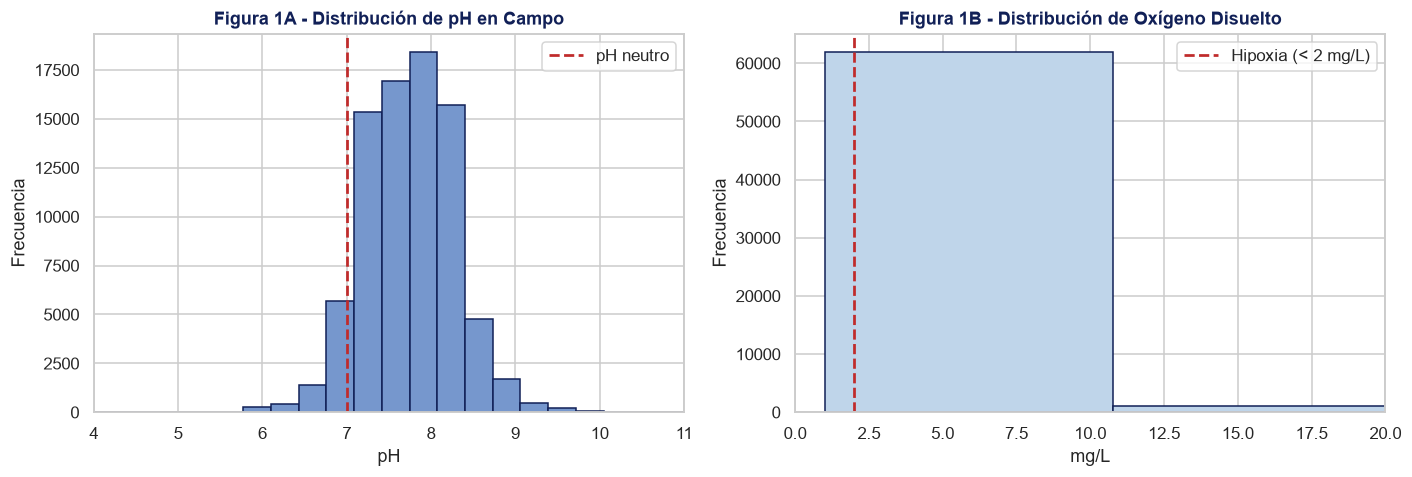

In [8]:
# Creamos una figura con dos gráficos
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico de distribución del pH
axs[0].hist(df_eda["pH_CAMPO"].dropna(), bins=30, color=AZUL, edgecolor=AZUL_OSCURO)
axs[0].axvline(7, color=ROJO, linestyle="--", linewidth=1.8, label="pH neutro")
axs[0].set_title("Figura 1A - Distribución de pH en Campo")
axs[0].set_xlabel("pH")
axs[0].set_ylabel("Frecuencia")
axs[0].set_xlim(4, 11)
axs[0].legend()

# Gráfico de distribución del oxígeno disuelto
axs[1].hist(df_eda["OD_mg/L"].dropna(), bins=30, color=AZUL_CLARO, edgecolor=AZUL_OSCURO)
axs[1].axvline(2, color=ROJO, linestyle="--", linewidth=1.8, label="Hipoxia (< 2 mg/L)")
axs[1].set_title("Figura 1B - Distribución de Oxígeno Disuelto")
axs[1].set_xlabel("mg/L")
axs[1].set_ylabel("Frecuencia")
axs[1].set_xlim(0, 20)
axs[1].legend()

# Ajustamos el espacio entre los gráficos
plt.tight_layout()

# Mostrar la figura
plt.show()

**Lectura de las Figuras 1A y 1B**  
El pH presenta una concentración de valores principalmente entre 7.3 y 8.3, con una mediana de 7.79, lo que indica una tendencia hacia valores ligeramente básicos. El oxígeno disuelto presenta una mediana de 6.20 mg/L y un rango de 1.00 a 294.60 mg/L. Se identifican muestras con valores inferiores a 2 mg/L, las cuales representan condiciones de baja disponibilidad de oxígeno y requieren revisión particular de los sitios donde fueron registradas. Esta distribución sugiere que, si bien la mayoría de los sitios presentan un pH aceptable para la vida acuática, los casos extremos de oxígeno disuelto podrían estar fuertemente asociados a cuerpos de agua con alta carga orgánica o contaminación.

### 5. Análisis Bivariado

Relaciones entre pares de variables con justificación técnica:

* **DBO frente a DQO:** Contrasta la materia orgánica biodegradable contra la carga de sustancias oxidables.

* **Tipo de agua frente a DQO:** Identifica qué tipo de cuerpo hídrico presenta mayores valores de carga contaminante.

DBO: Demanda Bioquímica de Oxígeno. Mide el oxígeno que necesitan los microorganismos para descomponer la materia orgánica biodegradable del agua.

DQO: Demanda Química de Oxígeno. Mide el oxígeno necesario para oxidar químicamente las sustancias oxidables presentes en el agua.

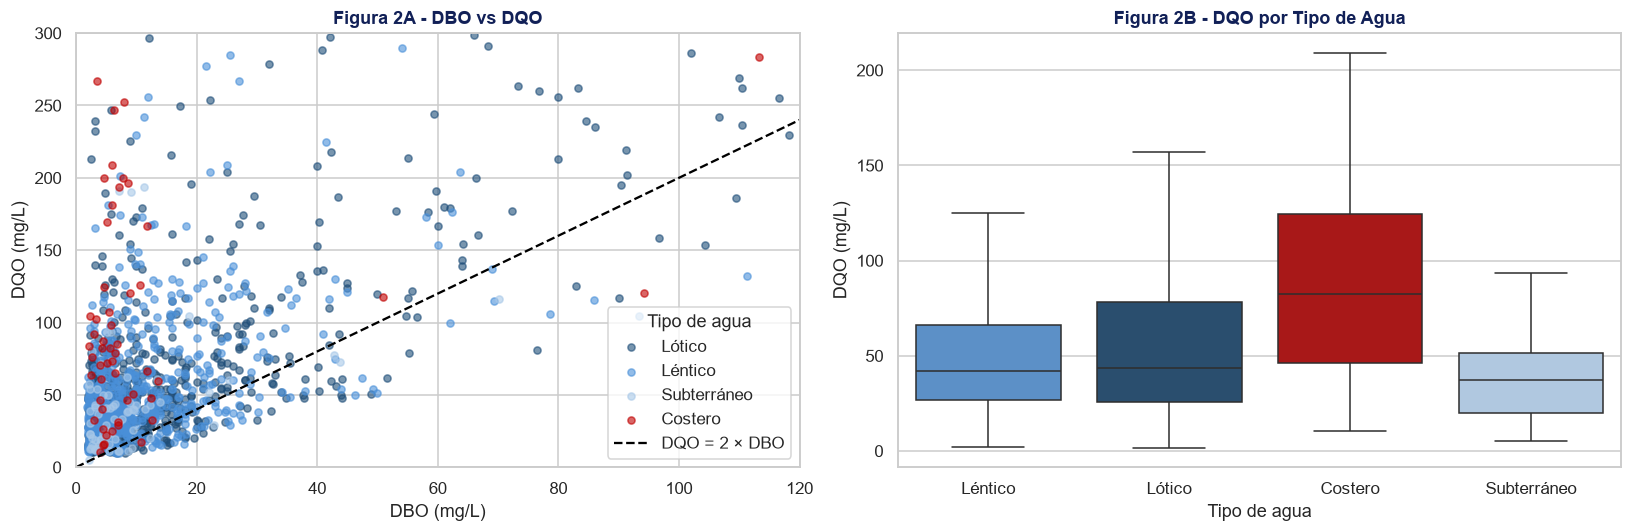

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

colores = {"Lótico":"#1f4e79", "Léntico":"#4a90d9",
           "Subterráneo":"#a8c8e8", "Costero":"#c00000"}

# 1) Filtramos la informacion 
df = df_eda[(df_eda.DBO_TOT.between(1,119)) & (df_eda.DQO_TOT.between(1,299))].dropna(subset=["DBO_TOT","DQO_TOT","TIPO CUERPO DE AGUA"]).copy() 
#Recordemos que  dropna: elimina filas con valores nulos

def tipo(t):
    t = str(t).upper()          # Convierte a texto en MAYÚSCULAS

    if "LOT" in t or "LÓT" in t:
        return "Lótico"
    if "LEN" in t or "LÉN" in t:
        return "Léntico"
    if "SUB" in t:
        return "Subterráneo"
    if "COST" in t:
        return "Costero"

    return "Otro"               # Si no encontró nada

df["TIPO_AGUA_GRAFICA"] = df["TIPO CUERPO DE AGUA"].apply(tipo)

#Generamos los graficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

for nombre, color in colores.items():
    g = df[df.TIPO_AGUA_GRAFICA == nombre]
    g = g.sample(min(len(g), 650), random_state=42) # hace que el azar sea siempre el mismo tomamos 650 muestras solo para el analisis de esta practica
    ax1.scatter(g.DBO_TOT, g.DQO_TOT, color=color, s=22, alpha=0.6, label=nombre)

ax1.plot([0,120],[0,240],"k--",lw=1.5,label="DQO = 2 × DBO")
ax1.set(title="Figura 2A - DBO vs DQO", xlabel="DBO (mg/L)", ylabel="DQO (mg/L)", xlim=(0,120), ylim=(0,300))
ax1.legend(title="Tipo de agua")

sns.boxplot(data=df, x="TIPO_AGUA_GRAFICA", y="DQO_TOT", hue="TIPO_AGUA_GRAFICA", palette=colores, showfliers=False, legend=False, ax=ax2)

ax2.set(title="Figura 2B - DQO por Tipo de Agua", xlabel="Tipo de agua", ylabel="DQO (mg/L)")

plt.tight_layout()
plt.show()

La relación DBO–DQO exhibe una correlación ascendente continua, donde la magnitud de DQO excede por encima a la DBO; la mayoría de los puntos se ubican por encima de la recta DQO = 2×DBO, lo que sugiere predominio de carga orgánica poco biodegradable (Aguasresiduales.info, s.f.). En la distribución por tipo de agua, los cuerpos costeros presentan las medianas y rangos intercuartílicos de DQO más elevados, seguidos por los lóticos, mientras que los subterráneos registran los valores más bajos. Por lo tanto los ríos y costas presentan mayor contaminación orgánica que los acuíferos.

---

### 6. Vista Multivariada
Matriz de correlacion conjunta y dispersion tridimensional por categoria hidrologica.

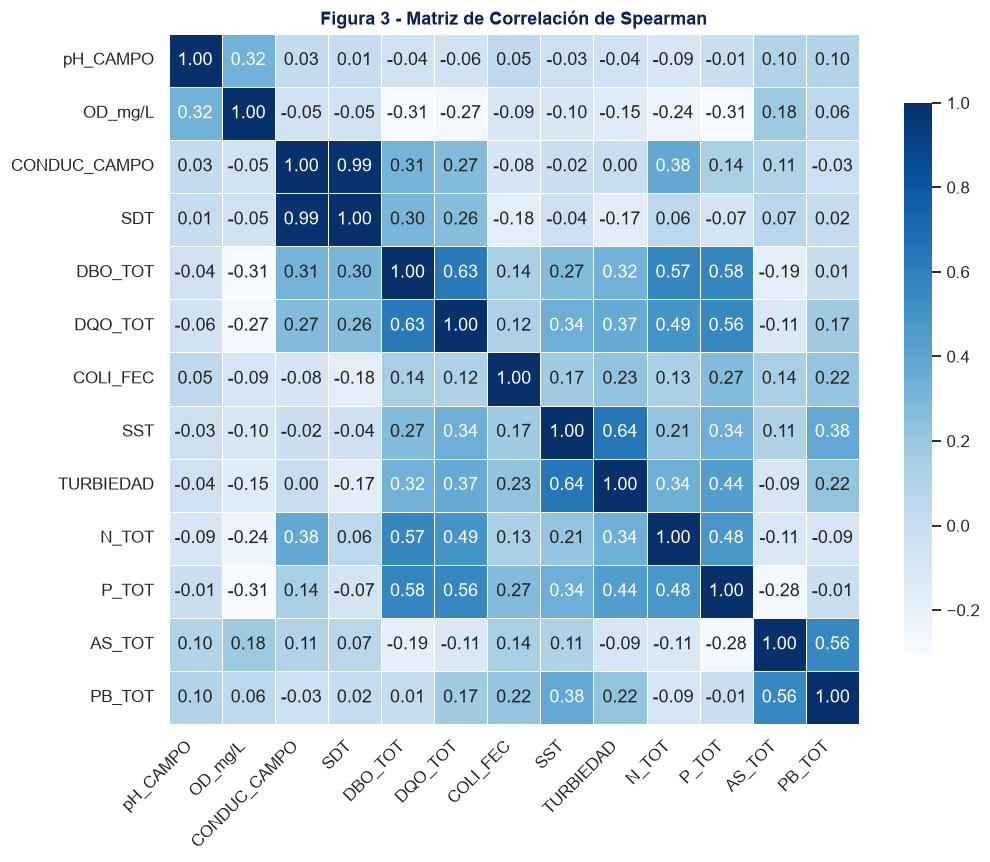

In [10]:
# 1) Definimos las columnas numéricas a correlacionar
cols_num = [
    "pH_CAMPO",       # pH medido en campo
    "OD_mg/L",        # Oxígeno Disuelto (mg/L)
    "CONDUC_CAMPO",   # Conductividad medida en campo (µS/cm)
    "SDT",            # Sólidos Disueltos Totales (mg/L)
    "DBO_TOT",        # Demanda Bioquímica de Oxígeno Total (mg/L)
    "DQO_TOT",        # Demanda Química de Oxígeno Total (mg/L)
    "COLI_FEC",       # Coliformes Fecales (NMP/100 mL)
    "SST",            # Sólidos Suspendidos Totales (mg/L)
    "TURBIEDAD",      # Turbiedad (NTU)
    "N_TOT",          # Nitrógeno Total (mg/L)
    "P_TOT",          # Fósforo Total (mg/L)
    "AS_TOT",         # Arsénico Total (mg/L)
    "PB_TOT"          # Plomo Total (mg/L)
]

# 2) Calculamos la matriz de correlación de Spearman
corr = df_eda[cols_num].corr(method="spearman")
#  Usamos Spearman ya que mide relaciones monótonas (si una sube, la otra tiende a subir), no solo lineales. Es más robusto cuando hay valores atípicos o distribuciones no normales, como en datos ambientales.


# 3) Graficamos el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5, square=True,cbar_kws={"shrink": 0.8})
plt.title("Figura 3 - Matriz de Correlación de Spearman")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Lectura de las Figuras 3.**  

La Conductividad y Sólidos Disueltos Totales correlacionan 0.99 (miden lo mismo). Demanda Bioquímica de Oxígeno, Demanda Química de Oxígeno, Nitrógeno Total y Fósforo Total se asocian entre 0.49 y 0.63, confirmando origen común de contaminación orgánica y nutrientes. El Oxígeno Disuelto correlaciona negativamente con ellas (−0.24 a −0.31) por consumo durante la degradación. Sólidos Suspendidos Totales y Turbiedad se asocian en 0.64. Arsénico y Plomo en 0.56, por origen geológico o industrial. pH y Coliformes Fecales muestran correlaciones débiles, indicando factores locales no capturados.

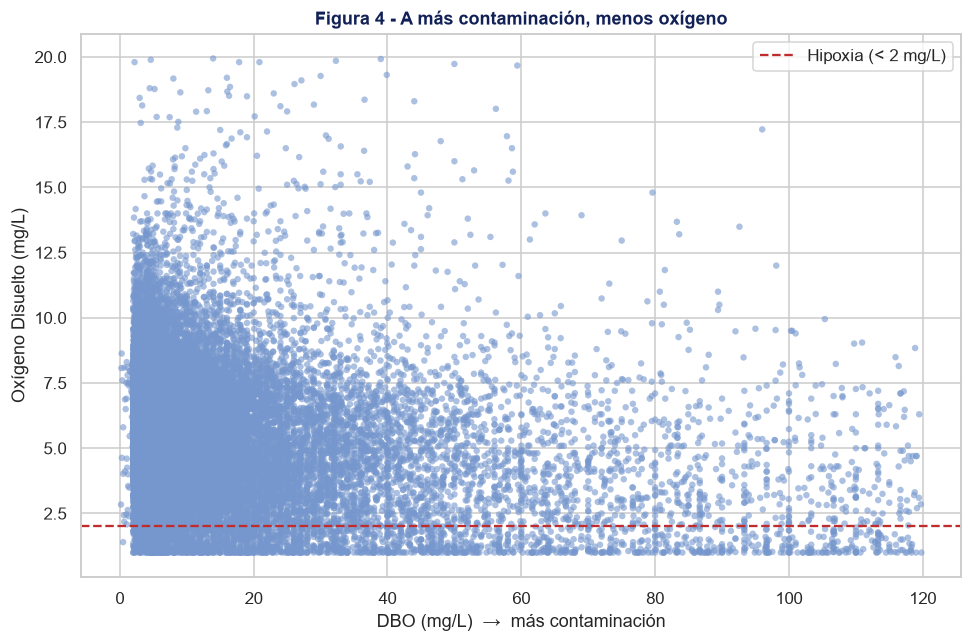

In [11]:
# Filtramos datos razonables
df_ok = df_eda[
    (df_eda["DBO_TOT"] > 0) & (df_eda["DBO_TOT"] < 120) &
    (df_eda["OD_mg/L"] > 0) & (df_eda["OD_mg/L"] < 20)
].dropna(subset=["DBO_TOT", "OD_mg/L"])

# Figura
plt.figure(figsize=(9, 6))

plt.scatter(
    df_ok["DBO_TOT"],
    df_ok["OD_mg/L"],
    color=AZUL,
    s=18,
    alpha=0.6,
    edgecolors="none"
)

# Línea de hipoxia
plt.axhline(2, color=ROJO, linestyle="--", linewidth=1.5,
            label="Hipoxia (< 2 mg/L)")

plt.title("Figura 4 - A más contaminación, menos oxígeno")
plt.xlabel("DBO (mg/L)  →  más contaminación")
plt.ylabel("Oxígeno Disuelto (mg/L)")
plt.legend()
plt.tight_layout()
plt.show()

**Lectura de las Figuras 4.**  
La gráfica muestra que, a mayor DBO (más contaminación orgánica), el oxígeno disuelto disminuye. La mayoría de los puntos caen por debajo del umbral de hipoxia (2 mg/L) cuando la DBO supera los 40 mg/L, lo que confirma que la contaminación consume el oxígeno del agua y pone en riesgo la vida acuática.

---

### 7. Conclusiones

Los ríos concentran la mayor contaminación del dataset, con valores de DQO y coliformes superiores a los de los pozos subterráneos, y la relación DQO/DBO confirma que esa carga proviene principalmente de descargas orgánicas urbanas y agrícolas. El oxígeno y el pH se mantienen estables en general, excepto en zonas con descargas directas donde aparecen episodios de hipoxia. Quedan preguntas abiertas: cómo varía la contaminación entre temporada seca y lluviosa, qué zonas superan los límites de arsénico y plomo, y si es posible estimar coliformes a partir de conductividad y turbiedad. Antes de cualquier análisis posterior será necesario corregir tres problemas: convertir correctamente los valores con "<" o ">", descartar o rellenar columnas con muchos datos vacíos como los plaguicidas, y aplicar logaritmo a variables muy sesgadas como los coliformes fecales.

### 8. Referencias y herramientas utilizadas

Aguasresiduales.info. (s.f.). *Análisis, comparativas y relaciones entre la DBO, DQO, COT*. Recuperado de https://www.aguasresiduales.info/revista/blog/analisis-comparativas-y-relaciones-entre-la-dbo-dqo-cot

Comisión Nacional del Agua. (2025, 6 de mayo). Resultados de la Red Nacional de Medición de Calidad del Agua (RENAMECA). Gobierno de México. Consultar fuente oficial de CONAGUA

Comisión Nacional del Agua. (2025, 18 de agosto). Indicadores de calidad del agua. Gobierno de México. Consultar fuente oficial de CONAGUA

Winton, R. S., López-Casas, S., Valencia-Rodríguez, D., Bernal-Forero, C., Delgado, J., Wehrli, B., & Jiménez-Segura, L. (2023). Patrones y factores impulsores de cambios en la calidad del agua asociados a embalses en los Andes tropicales. SciELO Preprints. https://doi.org/10.1590/SciELOPreprints.5549 

**NOTA:** Se utilizó ChatGPT como apoyo para explicar y agregar comentarios a funciones que desconocía. Por ejemplo, se recomendó utilizar `corr = df_eda[cols_num].corr(method="spearman")` para calcular la matriz de correlación de las variables numéricas, así como `stats = df_eda[variables].describe().T` para obtener las estadísticas descriptivas de varias variables sin calcular cada una de forma independiente. También se utilizó `engine="calamine"` para leer correctamente archivos de Excel en formato `.xlsb`.
